## 1.import des bibliotheques

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)
import matplotlib.patches as mpatches
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
import collections


## 2.charger les datasets

In [3]:
df_a = pd.read_csv("../Partie 1/Arkansas/Arkansas_full_clean.csv")
df_c = pd.read_csv("../Partie 1/california/California_combined_cleaned.csv")

## 3. eda


### .l'arkansas

In [4]:
df_a.info()
df_a.head()

<class 'pandas.DataFrame'>
RangeIndex: 9981 entries, 0 to 9980
Columns: 364 entries, B11_T0 to crop_name
dtypes: float64(362), int64(1), str(1)
memory usage: 27.7 MB


,B11_T0,B11_T1,B11_T10,B11_T11,B11_T12,B11_T13,B11_T14,B11_T15,B11_T16,B11_T17,...,B8_T4,B8_T5,B8_T6,B8_T7,B8_T8,B8_T9,crop_label,latitude,longitude,crop_name
0,3181.0,4241.0,5396.0,3931.0,4168.0,5218.0,0.0,0.0,3420.0,3276.0,...,0.0,5988.0,3051.0,3816.0,3416.0,3095.0,1,35.121630,-91.152407,Corn
1,3030.5,3529.5,5096.5,0.0,4901.5,4917.5,0.0,0.0,2766.0,2644.0,...,0.0,8876.5,3010.0,0.0,3217.0,3449.0,1,34.193840,-91.904585,Corn
2,3493.0,3742.0,4504.0,3782.0,4722.5,5072.0,5876.0,0.0,2652.0,2408.0,...,0.0,3533.0,2909.0,3913.0,3854.0,3244.0,1,34.581495,-91.237711,Corn
3,3344.5,4226.0,4617.0,3485.0,3645.0,0.0,3964.0,0.0,3116.5,2631.0,...,11080.0,0.0,2384.0,3112.0,0.0,3112.0,1,35.784738,-90.274934,Corn
4,3232.0,3589.0,5048.0,3738.0,4531.5,4309.0,2739.5,0.0,2602.5,2758.0,...,10928.0,3100.0,2771.0,3496.0,3298.0,2708.0,1,34.205083,-91.286998,Corn


In [5]:
df_a['crop_name'].value_counts()

crop_name
Soybeans    4680
Rice        2341
Corn        1501
Cotton       794
Others       665
Name: count, dtype: int64

In [6]:
df_a['crop_label'].value_counts()

crop_label
5      4680
3      2341
1      1501
2       794
176     553
61       51
121      24
190      12
122       7
141       5
123       4
37        4
10        2
143       1
26        1
152       1
Name: count, dtype: int64

### .la californie

In [7]:
df_c.info()
df_c.head()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 364 entries, B11_T0 to crop_name
dtypes: float64(362), int64(1), str(1)
memory usage: 27.8 MB


,B11_T0,B11_T1,B11_T10,B11_T11,B11_T12,B11_T13,B11_T14,B11_T15,B11_T16,B11_T17,...,B8_T4,B8_T5,B8_T6,B8_T7,B8_T8,B8_T9,crop_label,latitude,longitude,crop_name
0,2409.0,4156.0,4505.0,3896.5,3685.0,3586.5,3531.5,4007.5,3789.0,4167.0,...,2784.5,2957.5,0.0,2729.0,3417.0,4154.0,204,36.799028,-120.241320,Pistachios
1,2895.5,2761.0,2972.5,3661.5,3272.0,4209.0,3363.0,3145.0,4736.0,3914.5,...,4528.0,5300.0,6128.0,6546.0,4127.0,0.0,36,32.859796,-115.396121,Alfalfa
2,2280.0,2487.0,3365.0,1317.5,1592.5,1581.0,1966.0,2157.0,2321.5,2330.0,...,2139.0,2396.5,2442.0,2193.0,2239.0,2541.0,3,38.958441,-121.734122,Rice
3,4306.0,3965.0,3484.0,3412.0,5414.0,4433.0,3793.0,5312.0,4393.0,5560.5,...,4804.0,5624.0,6372.0,6428.0,5672.0,4784.0,36,35.261486,-118.998842,Alfalfa
4,3258.5,3488.0,3329.0,2984.0,2938.5,4218.0,3368.5,3126.0,4319.0,3502.0,...,4916.0,5122.0,5324.0,5638.0,6198.0,4212.0,36,32.684595,-115.446243,Alfalfa


In [8]:
df_c['crop_name'].value_counts()

crop_name
Others        3583
Rice          2021
Grapes        2011
Alfalfa        964
Almonds        793
Pistachios     628
Name: count, dtype: int64

In [9]:
df_c['crop_label'].value_counts()

crop_label
176    3259
69     2053
3      2037
36      974
75      783
204     640
61      209
1        45
Name: count, dtype: int64

## 4. data preprocessing

### . L'arkansas

In [10]:
nouvel_ordre = [
    'B2_T0','B3_T0','B4_T0','B5_T0','B6_T0','B7_T0','B8_T0','B8A_T0','B11_T0','B12_T0',
    'B2_T1','B3_T1','B4_T1','B5_T1','B6_T1','B7_T1','B8_T1','B8A_T1','B11_T1','B12_T1',
    'B2_T2','B3_T2','B4_T2','B5_T2','B6_T2','B7_T2','B8_T2','B8A_T2','B11_T2','B12_T2',
    'B2_T3','B3_T3','B4_T3','B5_T3','B6_T3','B7_T3','B8_T3','B8A_T3','B11_T3','B12_T3',
    'B2_T4','B3_T4','B4_T4','B5_T4','B6_T4','B7_T4','B8_T4','B8A_T4','B11_T4','B12_T4',
    'B2_T5','B3_T5','B4_T5','B5_T5','B6_T5','B7_T5','B8_T5','B8A_T5','B11_T5','B12_T5',
    'B2_T6','B3_T6','B4_T6','B5_T6','B6_T6','B7_T6','B8_T6','B8A_T6','B11_T6','B12_T6',
    'B2_T7','B3_T7','B4_T7','B5_T7','B6_T7','B7_T7','B8_T7','B8A_T7','B11_T7','B12_T7',
    'B2_T8','B3_T8','B4_T8','B5_T8','B6_T8','B7_T8','B8_T8','B8A_T8','B11_T8','B12_T8',
    'B2_T9','B3_T9','B4_T9','B5_T9','B6_T9','B7_T9','B8_T9','B8A_T9','B11_T9','B12_T9',
    'B2_T10','B3_T10','B4_T10','B5_T10','B6_T10','B7_T10','B8_T10','B8A_T10','B11_T10','B12_T10',
    'B2_T11','B3_T11','B4_T11','B5_T11','B6_T11','B7_T11','B8_T11','B8A_T11','B11_T11','B12_T11',
    'B2_T12','B3_T12','B4_T12','B5_T12','B6_T12','B7_T12','B8_T12','B8A_T12','B11_T12','B12_T12',
    'B2_T13','B3_T13','B4_T13','B5_T13','B6_T13','B7_T13','B8_T13','B8A_T13','B11_T13','B12_T13',
    'B2_T14','B3_T14','B4_T14','B5_T14','B6_T14','B7_T14','B8_T14','B8A_T14','B11_T14','B12_T14',
    'B2_T15','B3_T15','B4_T15','B5_T15','B6_T15','B7_T15','B8_T15','B8A_T15','B11_T15','B12_T15',
    'B2_T16','B3_T16','B4_T16','B5_T16','B6_T16','B7_T16','B8_T16','B8A_T16','B11_T16','B12_T16',
    'B2_T17','B3_T17','B4_T17','B5_T17','B6_T17','B7_T17','B8_T17','B8A_T17','B11_T17','B12_T17',
    'B2_T18','B3_T18','B4_T18','B5_T18','B6_T18','B7_T18','B8_T18','B8A_T18','B11_T18','B12_T18',
    'B2_T19','B3_T19','B4_T19','B5_T19','B6_T19','B7_T19','B8_T19','B8A_T19','B11_T19','B12_T19',
    'B2_T20','B3_T20','B4_T20','B5_T20','B6_T20','B7_T20','B8_T20','B8A_T20','B11_T20','B12_T20',
    'B2_T21','B3_T21','B4_T21','B5_T21','B6_T21','B7_T21','B8_T21','B8A_T21','B11_T21','B12_T21',
    'B2_T22','B3_T22','B4_T22','B5_T22','B6_T22','B7_T22','B8_T22','B8A_T22','B11_T22','B12_T22',
    'B2_T23','B3_T23','B4_T23','B5_T23','B6_T23','B7_T23','B8_T23','B8A_T23','B11_T23','B12_T23',
    'B2_T24','B3_T24','B4_T24','B5_T24','B6_T24','B7_T24','B8_T24','B8A_T24','B11_T24','B12_T24',
    'B2_T25','B3_T25','B4_T25','B5_T25','B6_T25','B7_T25','B8_T25','B8A_T25','B11_T25','B12_T25',
    'B2_T26','B3_T26','B4_T26','B5_T26','B6_T26','B7_T26','B8_T26','B8A_T26','B11_T26','B12_T26',
    'B2_T27','B3_T27','B4_T27','B5_T27','B6_T27','B7_T27','B8_T27','B8A_T27','B11_T27','B12_T27',
    'B2_T28','B3_T28','B4_T28','B5_T28','B6_T28','B7_T28','B8_T28','B8A_T28','B11_T28','B12_T28',
    'B2_T29','B3_T29','B4_T29','B5_T29','B6_T29','B7_T29','B8_T29','B8A_T29','B11_T29','B12_T29',
    'B2_T30','B3_T30','B4_T30','B5_T30','B6_T30','B7_T30','B8_T30','B8A_T30','B11_T30','B12_T30',
    'B2_T31','B3_T31','B4_T31','B5_T31','B6_T31','B7_T31','B8_T31','B8A_T31','B11_T31','B12_T31',
    'B2_T32','B3_T32','B4_T32','B5_T32','B6_T32','B7_T32','B8_T32','B8A_T32','B11_T32','B12_T32',
    'B2_T33','B3_T33','B4_T33','B5_T33','B6_T33','B7_T33','B8_T33','B8A_T33','B11_T33','B12_T33',
    'B2_T34','B3_T34','B4_T34','B5_T34','B6_T34','B7_T34','B8_T34','B8A_T34','B11_T34','B12_T34',
    'B2_T35','B3_T35','B4_T35','B5_T35','B6_T35','B7_T35','B8_T35','B8A_T35','B11_T35','B12_T35',
    'crop_label','latitude','longitude','crop_name'
]
df_a=df_a[nouvel_ordre]


In [11]:
df_a.head()

,B2_T0,B3_T0,B4_T0,B5_T0,B6_T0,B7_T0,B8_T0,B8A_T0,B11_T0,B12_T0,...,B6_T35,B7_T35,B8_T35,B8A_T35,B11_T35,B12_T35,crop_label,latitude,longitude,crop_name
0,1948.0,1971.0,2066.0,2391.0,2699.0,2850.0,2992.0,3107.0,3181.0,2356.0,...,2583.0,2749.0,2914.0,3005.0,3873.0,3208.0,1,35.121630,-91.152407,Corn
1,1327.0,1543.0,1674.0,2222.5,2948.5,3173.0,3413.5,3450.0,3030.5,2250.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1,34.193840,-91.904585,Corn
2,1578.0,1900.0,2305.0,2684.0,2891.0,3028.0,3138.0,3226.0,3493.0,2851.0,...,3395.0,3637.0,3648.0,3763.0,3708.0,3046.0,1,34.581495,-91.237711,Corn
3,1592.0,1723.0,1890.0,2112.0,2232.0,2337.5,2579.0,2557.5,3344.5,2666.0,...,2730.0,2846.0,3177.0,3101.5,2680.0,2024.0,1,35.784738,-90.274934,Corn
4,1561.0,1870.0,1932.0,2632.5,3458.0,3638.5,3844.0,3850.0,3232.0,2393.0,...,2671.0,2793.0,2970.0,2998.0,3206.0,2498.0,1,34.205083,-91.286998,Corn


In [12]:

df_a_x = df_a.drop(columns=['crop_label','latitude','longitude','crop_name'])
X_a = df_a_x.values
df_a_y =df_a[['crop_name','crop_label']]
df_a_y.loc[df_a['crop_name'] == 'Others', 'crop_label'] = 0
df_a_y.loc[df_a['crop_label'] == 5, 'crop_label'] = 4
y_a = df_a_y['crop_label'].values

In [13]:

X_a = X_a.reshape(-1, 36, 10)


In [14]:

mask_a = (X_a != 0).astype(float)


X_flat = X_a.reshape(-1, 360)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat).reshape(-1, 36, 10).astype(np.float32)
X_a = X_scaled


In [15]:
def split_par_classe(df, X, y, mask, train_ratio=0.70, val_ratio=0.15, random_state=42):
    
    train_idx, val_idx, test_idx = [], [], []
    for classe in np.unique(y):
        idx_c = np.where(y == classe)[0]
        rng = np.random.RandomState(random_state)
        idx_c = rng.permutation(idx_c)
        n = len(idx_c)
        n_tr = int(n * train_ratio)
        n_v  = int(n * val_ratio)
        train_idx.extend(idx_c[:n_tr])
        val_idx.extend(idx_c[n_tr:n_tr+n_v])
        test_idx.extend(idx_c[n_tr+n_v:])
    ti, vi, tei = np.array(train_idx), np.array(val_idx), np.array(test_idx)
    import collections
    print(f'  Train:{len(ti)} | Val:{len(vi)} | Test:{len(tei)}')
    print('  Distrib train:', dict(sorted(collections.Counter(y[ti].tolist()).items())))
    print('  Distrib test :', dict(sorted(collections.Counter(y[tei].tolist()).items())))
    return (X[ti], X[vi], X[tei],
            y[ti], y[vi], y[tei],
            mask[ti], mask[vi], mask[tei],
            tei)   

(X_a_train, X_a_val, X_a_test,
 y_a_train, y_a_val, y_a_test,
 mask_a_train, mask_a_val, mask_a_test,
 test_idx_a) = split_par_classe(
    df_a, X_a, y_a, mask=mask_a,
    train_ratio=0.70, val_ratio=0.15, random_state=42
)

coords_test_a = df_a.iloc[test_idx_a][['latitude', 'longitude']].values





  Train:6984 | Val:1496 | Test:1501
  Distrib train: {0: 465, 1: 1050, 2: 555, 3: 1638, 4: 3276}
  Distrib test : {0: 101, 1: 226, 2: 120, 3: 352, 4: 702}


### . la californie

In [16]:
df_c = df_c[nouvel_ordre]

In [17]:
X_c = df_c.drop(columns=['crop_label','latitude','longitude','crop_name']).values

df_c_y = df_c[['crop_label']].copy()

keep = [3, 36, 69, 75, 204]

df_c_y['crop_label'] = df_c_y['crop_label'].apply(lambda x: x if x in keep else 0)


df_c_y['crop_label'] = df_c_y['crop_label'].replace({
    3: 1,
    36: 2,
    69: 3,
    75: 4,
    204: 5
})

y_c = df_c_y['crop_label'].values

print(sorted(np.unique(y_c)))



[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [18]:

X_c = X_c.reshape(-1, 36, 10)        
mask_c = (X_c != 0).astype(float)    

X_flat = X_c.reshape(-1, 360)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat).reshape(-1, 36, 10).astype(np.float32)
X_c = X_scaled

In [19]:
(X_c_train, X_c_val, X_c_test,
 y_c_train, y_c_val, y_c_test,
 mask_c_train, mask_c_val, mask_c_test,
 test_idx_c) = split_par_classe(
    df_c, X_c, y_c, mask=mask_c,
    train_ratio=0.70, val_ratio=0.15, random_state=42
)

coords_test_c = df_c.iloc[test_idx_c][['latitude', 'longitude']].values


  Train:6998 | Val:1497 | Test:1505
  Distrib train: {0: 2459, 1: 1425, 2: 681, 3: 1437, 4: 548, 5: 448}
  Distrib test : {0: 528, 1: 307, 2: 147, 3: 309, 4: 118, 5: 96}


## 5. le modele

### .l'arkansas

In [20]:
def CNNBlock(x, filters=64):
    
    dim = x.shape[-1]
    
    shortcut = x if dim == filters else layers.Conv1D(filters, kernel_size=1, padding='same')(x)
    x = layers.Conv1D(filters=filters, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv1D(filters=filters, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x


In [21]:
def TransformerBlock(x, num_heads=5, dropout=0.2):
    
    dim = x.shape[-1]
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim)(x, x)
    attn = layers.Dropout(dropout)(attn)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)
    ff = layers.Dense(dim * 2, activation='gelu')(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(dim)(ff)
    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)
    return x


In [22]:
def get_sinusoidal_PE(T=36, d_model=10):
    pe = np.zeros((T, d_model))
    for t in range(T):
        for i in range(0, d_model, 2):
            pe[t, i]   = np.sin(t / (10000 ** (2*i / d_model)))
            if i+1 < d_model:
                pe[t, i+1] = np.cos(t / (10000 ** (2*i / d_model)))
    return tf.constant(pe[np.newaxis, :, :], dtype=tf.float32)

PE_MATRIX = get_sinusoidal_PE(T=36, d_model=10) * 0.1


def ALPE(x, mask):

    C = x.shape[-1]
    pe_broadcast = layers.Lambda(lambda inp: inp[0] + tf.zeros_like(inp[1]))([PE_MATRIX, x])
    pe_masked    = layers.Multiply()([pe_broadcast, mask])
    x_conv = layers.Conv1D(filters=C, kernel_size=3, padding='same')(pe_masked)
    k = max(3, (int(math.log2(C) / 2 + 0.5) * 2) - 1)  
    w = layers.GlobalAveragePooling1D()(x_conv)
    w = layers.Reshape((C, 1))(w)
    w = layers.Conv1D(filters=1, kernel_size=k, padding='same', use_bias=False)(w)
    w = layers.Activation('sigmoid')(w)
    w = layers.Reshape((1, C))(w)
    return layers.Multiply()([x_conv, w])

In [23]:
def TemporalAttention(lstm_out):
    
    
    score = layers.Dense(1, activation='tanh')(lstm_out)
    weight = layers.Softmax(axis=1)(score)           
    context = layers.Lambda(lambda inp: tf.reduce_sum(inp[0] * inp[1], axis=1))([lstm_out, weight])
    return context, weight


def RNNBranch(x, lstm_units=64, gru_units=32, dropout=0.1):

    bilstm_out = layers.Bidirectional(
        layers.LSTM(
            units=lstm_units,
            return_sequences=True,
            dropout=dropout,
            recurrent_dropout=0.2      
        )
    )(x)   


    context_lstm, _ = TemporalAttention(bilstm_out)
 
    gru_out = layers.GRU(
        units=gru_units,
        return_sequences=False,
        dropout=dropout,
        recurrent_dropout=0.1
    )(x)   
    fused = layers.Concatenate()([context_lstm, gru_out])
    return fused

In [24]:
def build_MCTNet_v2(input_shape=(36, 10), num_classes=5,
                    lstm_units=128, gru_units=64, dropout=0.2):
    
    inputs = tf.keras.Input(shape=input_shape)
    mask   = tf.keras.Input(shape=input_shape)

    
    cnn = CNNBlock(inputs)
    cnn = CNNBlock(cnn)                         
    cnn = layers.GlobalAveragePooling1D()(cnn)  


    trans_input = ALPE(inputs, mask) + inputs
    trans = TransformerBlock(trans_input, num_heads=5)
    trans = TransformerBlock(trans, num_heads=5)  
    trans = layers.GlobalAveragePooling1D()(trans)


    rnn = RNNBranch(inputs, lstm_units=lstm_units,
                    gru_units=gru_units, dropout=dropout)


    fused = layers.Concatenate()([cnn, trans, rnn])
    

    out = layers.Dense(256, activation='gelu')(fused)
    out = layers.Dropout(dropout)(out)
    out = layers.Dense(128, activation='gelu')(out)
    out = layers.Dropout(dropout / 2)(out)
    outputs = layers.Dense(num_classes, activation='softmax')(out)

    return tf.keras.Model(inputs=[inputs, mask], outputs=outputs)

In [25]:

def focal_loss(gamma=2.0, alpha=0.25, label_smoothing=0.1):    
    def loss_fn(y_true, y_pred):
        n_classes = y_pred.shape[-1]
        y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), n_classes)
        y_true_smooth = y_true_oh * (1 - label_smoothing) + label_smoothing / n_classes
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        ce = -tf.reduce_sum(y_true_smooth * tf.math.log(y_pred), axis=-1)
        p_t = tf.reduce_sum(y_true_oh * y_pred, axis=-1)
        focal_w = alpha * tf.pow(1.0 - p_t, gamma)
        return tf.reduce_mean(focal_w * ce)
    return loss_fn



class KappaMonitor(Callback):
    
    def __init__(self, val_data, patience=25):
        super().__init__()
        self.val_data  = val_data   
        self.patience  = patience
        self.best_kappa = -np.inf
        self.wait       = 0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        (X_v, m_v), y_v = self.val_data
        preds = self.model.predict([X_v, m_v], verbose=0).argmax(axis=1)
        kappa = cohen_kappa_score(y_v, preds)
        f1    = f1_score(y_v, preds, average='macro', zero_division=0)
        if logs: logs['val_kappa'] = kappa
        if kappa > self.best_kappa:
            self.best_kappa   = kappa
            self.wait         = 0
            self.best_weights = self.model.get_weights()
            print(f'  ✔ Epoch {epoch+1:3d} — val_kappa={kappa:.4f}  val_f1={f1:.4f}  [BEST]')
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f'\n⏹ Early stopping epoch {epoch+1} — best kappa={self.best_kappa:.4f}')
                self.model.set_weights(self.best_weights)
                self.model.stop_training = True

    def on_train_end(self, logs=None):
        if self.best_weights:
            self.model.set_weights(self.best_weights)


In [26]:
model = build_MCTNet_v2(
    input_shape=(36, 10), num_classes=5,
    lstm_units=128, gru_units=64, dropout=0.2
)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=focal_loss(gamma=3.0, alpha=0.25, label_smoothing=0.05),
    metrics=['accuracy']
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 36, 10)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 36, 10)    │          0 │ lambda[0][0],     │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 36, 10)    │        310 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 10)        │          0 │ conv1d_5[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 10, 1)     │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 10, 1)     │          3 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 10, 1)     │          0 │ conv1d_6[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 10)     │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 36, 10)    │          0 │ conv1d_5[0][0],   │
│ (Multiply)          │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 36, 10)    │          0 │ multiply_1[0][0], │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 10)    │      2,160 │ add_2[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 36, 10)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 36, 10)    │          0 │ add_2[0][0],      │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 36, 10)    │         20 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 36, 64)    │      1,984 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 36, 20)    │        220 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 36, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 338,187 (1.29 MB)

 Trainable params: 337,675 (1.29 MB)

 Non-trainable params: 512 (2.00 KB)

In [27]:

cw_arr = compute_class_weight('balanced', classes=np.unique(y_a_train), y=y_a_train)
class_weight_a = {i: float(w) for i, w in enumerate(cw_arr)}


label_map = df_a.groupby('crop_label')['crop_name'].first().to_dict()
print('Label map Arkansas:', label_map)

for lbl, name in label_map.items():
    if name in ['Soybeans', 'Corn']:
        class_weight_a[lbl] = class_weight_a.get(lbl, 1.0) * 2.0

print('Class weights Arkansas:', class_weight_a)

kappa_cb = KappaMonitor(
    val_data=([X_a_val, mask_a_val], y_a_val), patience=30
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7, verbose=1
)

history = model.fit(
    [X_a_train, mask_a_train], y_a_train,
    validation_data=([X_a_val, mask_a_val], y_a_val),
    epochs=150, batch_size=64,
    callbacks=[kappa_cb, reduce_lr],
    class_weight=class_weight_a,
    verbose=1
)


Label map Arkansas: {1: 'Corn', 2: 'Cotton', 3: 'Rice', 5: 'Soybeans', 10: 'Others', 26: 'Others', 37: 'Others', 61: 'Others', 121: 'Others', 122: 'Others', 123: 'Others', 141: 'Others', 143: 'Others', 152: 'Others', 176: 'Others', 190: 'Others'}
Class weights Arkansas: {0: 3.0038709677419355, 1: 2.6605714285714286, 2: 2.516756756756757, 3: 0.8527472527472527, 4: 0.42637362637362636, 5: 2.0}
Epoch 1/150
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.5920 - loss: 0.1389  ✔ Epoch   1 — val_kappa=0.6370  val_f1=0.7154  [BEST]
110/110 ━━━━━━━━━━━━━━━━━━━━ 72s 290ms/step - accuracy: 0.6917 - loss: 0.0976 - val_accuracy: 0.7587 - val_loss: 0.0613 - val_kappa: 0.6370 - learning_rate: 3.0000e-04
Epoch 2/150
110/110 ━━━━━━━━━━━━━━━━━━━━ 21s 193ms/step - accuracy: 0.8734 - loss: 0.0331 - val_accuracy: 0.6885 - val_loss: 0.0658 - val_kappa: 0.5643 - learning_rate: 3.0000e-04
Epoch 3/150
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.8972 - loss: 0.0267  ✔ Epoch   3 — val_kappa

In [28]:
y_a_pred = model.predict([X_a_test, mask_a_test]).argmax(axis=1)

oa    = accuracy_score(y_a_test, y_a_pred)
f1    = f1_score(y_a_test, y_a_pred, average='macro')
kappa = cohen_kappa_score(y_a_test, y_a_pred)

print(f'OA    : {oa:.4f}')
print(f'F1    : {f1:.4f}')
print(f'Kappa : {kappa:.4f}')
print()
print(classification_report(y_a_test, y_a_pred,
      target_names=['Soybeans','Rice','Corn','Cotton','Others']))


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
OA    : 0.9773
F1    : 0.9684
Kappa : 0.9673

              precision    recall  f1-score   support

    Soybeans       0.95      0.89      0.92       101
        Rice       0.97      0.98      0.98       226
        Corn       0.98      0.97      0.98       120
      Cotton       0.99      0.99      0.99       352
      Others       0.98      0.98      0.98       702

    accuracy                           0.98      1501
   macro avg       0.97      0.96      0.97      1501
weighted avg       0.98      0.98      0.98      1501



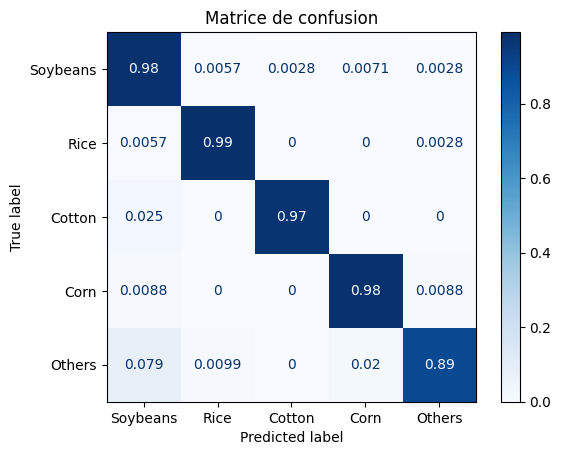

In [29]:
labels = ["Soybeans", "Rice", "Cotton", "Corn", "Others"]
cm = confusion_matrix(y_a_test, y_a_pred,labels=[4,3,2,1,0])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm,display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.show()



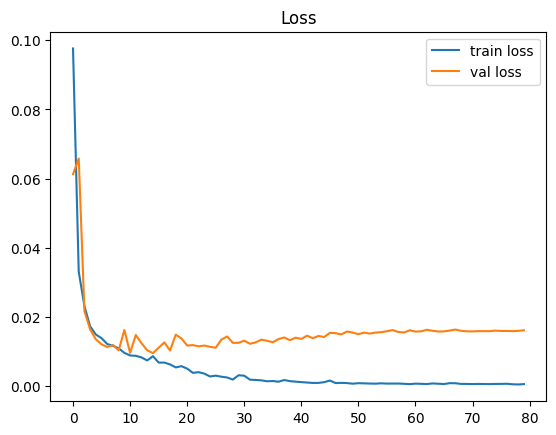

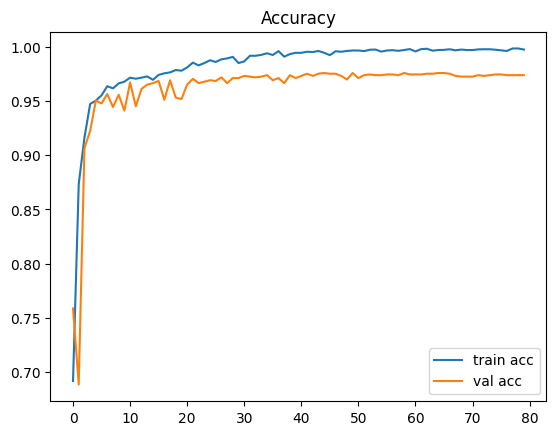

In [30]:
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")

plt.legend()
plt.title("Loss")
plt.show()

plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")

plt.legend()
plt.title("Accuracy")
plt.show()

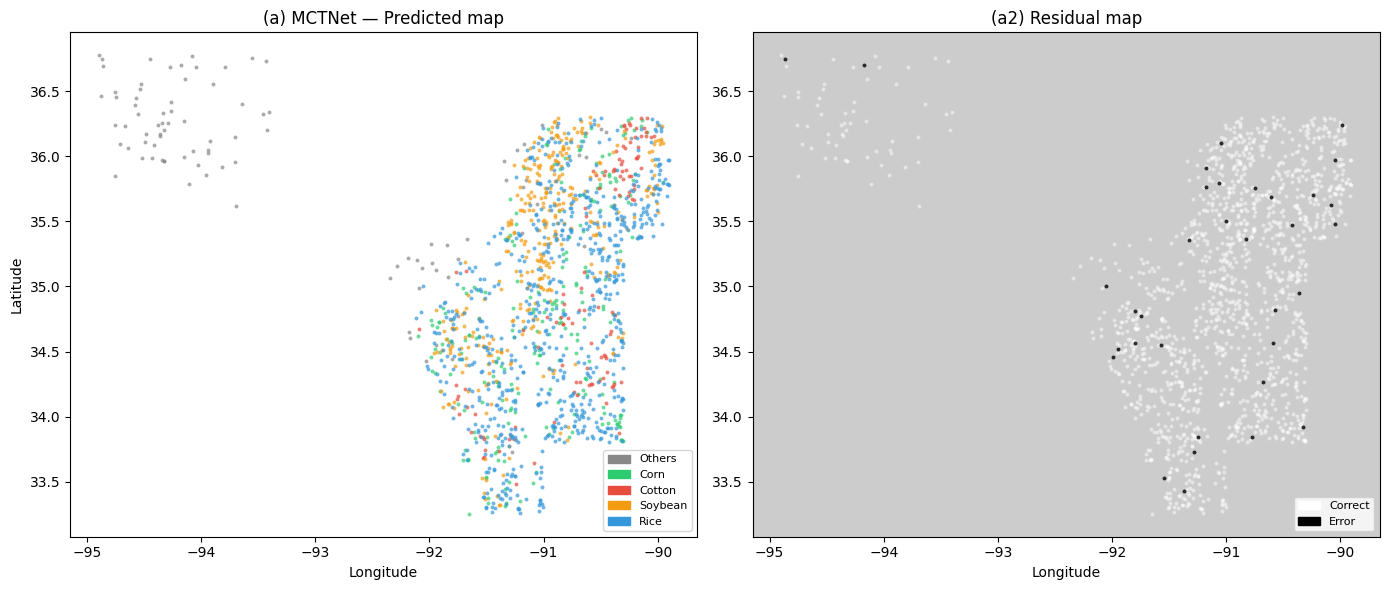

Mapping accuracy : 0.977


In [38]:
LABEL_MAP = {
    0: 'Others',
    1: 'Corn',
    2: 'Cotton',
    3: 'Soybean',
    4: 'Rice',
}

COLOR_MAP = {
    0: '#888888',   # Others  → gris
    1: '#2ecc71',   # Corn    → vert
    2: '#e74c3c',   # Cotton  → rouge
    3: '#f39c12',   # Soybean → orange
    4: '#3498db',   # Rice    → bleu
}


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

lats = coords_test_a[:, 0]
lons = coords_test_a[:, 1]


ax = axes[0]
for classe, color in COLOR_MAP.items():
    mask_classe = y_a_pred == classe
    if mask_classe.sum() > 0:
        ax.scatter(
            lons[mask_classe], lats[mask_classe],
            c=color, s=8, label=LABEL_MAP[classe],
            alpha=0.7, linewidths=0
        )

ax.set_title('(a) MCTNet — Predicted map', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')


patches = [mpatches.Patch(color=COLOR_MAP[c], label=LABEL_MAP[c])
           for c in COLOR_MAP]
ax.legend(handles=patches, loc='lower right', fontsize=8, markerscale=3)


ax = axes[1]
correct = y_a_pred == y_a_test

ax.scatter(
    lons[correct], lats[correct],
    c='white', s=8, alpha=0.5, linewidths=0,
    label='Correct'
)
ax.scatter(
    lons[~correct], lats[~correct],
    c='black', s=8, alpha=0.8, linewidths=0,
    label='Error'
)

ax.set_facecolor('#cccccc')  
ax.set_title('(a2) Residual map', fontsize=12)
ax.set_xlabel('Longitude')

patches_res = [
    mpatches.Patch(color='white', label='Correct'),
    mpatches.Patch(color='black', label='Error')
]
ax.legend(handles=patches_res, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('crop_map_arkansas.png', dpi=300, bbox_inches='tight')
plt.show()


mapping_accuracy = correct.sum() / len(correct)
print(f"Mapping accuracy : {mapping_accuracy:.3f}")

### .la californie

In [32]:
model_c = build_MCTNet_v2(
    input_shape=(36, 10), num_classes=6,
    lstm_units=128, gru_units=64, dropout=0.2
)
model_c.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=focal_loss(gamma=3.0, alpha=0.25, label_smoothing=0.05),
    metrics=['accuracy']
)
model_c.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 36, 10)    │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 36, 10)    │          0 │ lambda_2[0][0],   │
│ (Multiply)          │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 36, 10)    │        310 │ multiply_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 10)        │          0 │ conv1d_12[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 10, 1)     │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 10, 1)     │          3 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 10, 1)     │          0 │ conv1d_13[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 10)     │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 36, 10)    │          0 │ conv1d_12[0][0],  │
│ (Multiply)          │                   │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 36, 10)    │          0 │ multiply_3[0][0], │
│                     │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 10)    │      2,160 │ add_9[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_9[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 36, 10)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 36, 10)    │          0 │ add_9[0][0],      │
│                     │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 36, 10)    │         20 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 36, 64)    │      1,984 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 36, 20)    │        220 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 64)    │        256 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 338,316 (1.29 MB)

 Trainable params: 337,804 (1.29 MB)

 Non-trainable params: 512 (2.00 KB)

In [33]:
cw_arr_c = compute_class_weight('balanced', classes=np.unique(y_c_train), y=y_c_train)
class_weight_c = {i: float(w) for i, w in enumerate(cw_arr_c)}
print('Class weights Californie:', class_weight_c)

kappa_cb_c = KappaMonitor(
    val_data=([X_c_val, mask_c_val], y_c_val), patience=30
)
reduce_lr_c = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7, verbose=1
)

history_c = model_c.fit(
    [X_c_train, mask_c_train], y_c_train,
    validation_data=([X_c_val, mask_c_val], y_c_val),
    epochs=150, batch_size=64,
    callbacks=[kappa_cb_c, reduce_lr_c],
    class_weight=class_weight_c,
    verbose=1
)


Class weights Californie: {0: 0.4743120509692287, 1: 0.8184795321637427, 2: 1.7126774351443954, 3: 0.8116446300162375, 4: 2.128345498783455, 5: 2.603422619047619}
Epoch 1/150
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.6419 - loss: 0.1255  ✔ Epoch   1 — val_kappa=0.7649  val_f1=0.7623  [BEST]
110/110 ━━━━━━━━━━━━━━━━━━━━ 61s 287ms/step - accuracy: 0.7625 - loss: 0.0815 - val_accuracy: 0.8176 - val_loss: 0.0639 - val_kappa: 0.7649 - learning_rate: 3.0000e-04
Epoch 2/150
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8742 - loss: 0.0387  ✔ Epoch   2 — val_kappa=0.8334  val_f1=0.8368  [BEST]
110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 176ms/step - accuracy: 0.8893 - loss: 0.0346 - val_accuracy: 0.8704 - val_loss: 0.0431 - val_kappa: 0.8334 - learning_rate: 3.0000e-04
Epoch 3/150
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9076 - loss: 0.0287  ✔ Epoch   3 — val_kappa=0.8554  val_f1=0.8447  [BEST]
110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 175ms/step - accuracy: 0.9141 - loss

In [34]:
y_c_pred = model_c.predict([X_c_test, mask_c_test])
y_c_pred = y_c_pred.argmax(axis=1)

oa = accuracy_score(y_c_test, y_c_pred)
f1 = f1_score(y_c_test, y_c_pred, average='macro')
kappa = cohen_kappa_score(y_c_test, y_c_pred)

print("OA:", oa)
print("F1:", f1)
print("Kappa:", kappa)

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
OA: 0.9654485049833887
F1: 0.951237153509033
Kappa: 0.9552285255962856


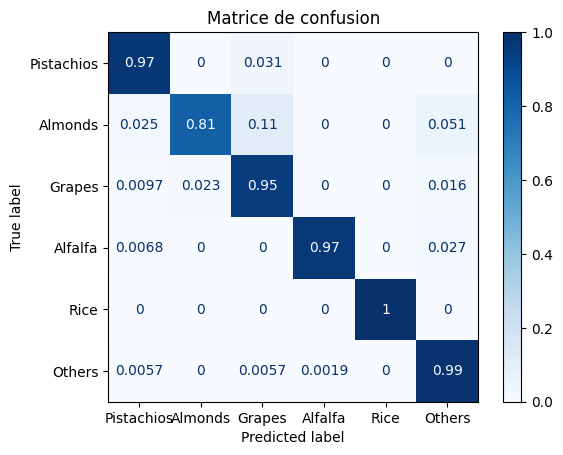


Classification Report :

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       528
           1       1.00      1.00      1.00       307
           2       0.99      0.97      0.98       147
           3       0.94      0.95      0.95       309
           4       0.93      0.81      0.87       118
           5       0.90      0.97      0.93        96

    accuracy                           0.97      1505
   macro avg       0.96      0.95      0.95      1505
weighted avg       0.97      0.97      0.97      1505



In [35]:
labels = ["Pistachios","Almonds","Grapes", "Alfalfa","Rice", "Others"]
cm_c = confusion_matrix(y_c_test, y_c_pred,labels=[5,4,3,2,1,0])
cm_norm_c = cm_c.astype(float) / cm_c.sum(axis=1, keepdims=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm_c,display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.show()

print("\nClassification Report :\n")
print(classification_report(y_c_test, y_c_pred))

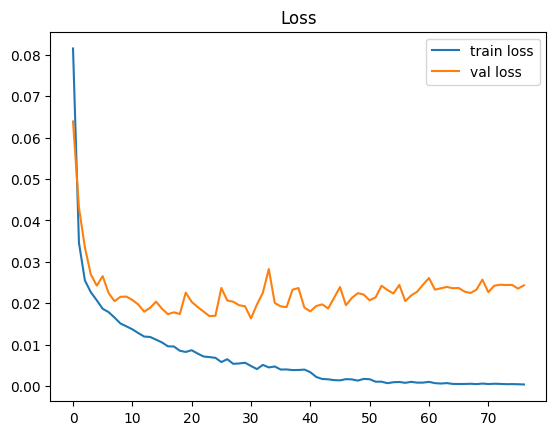

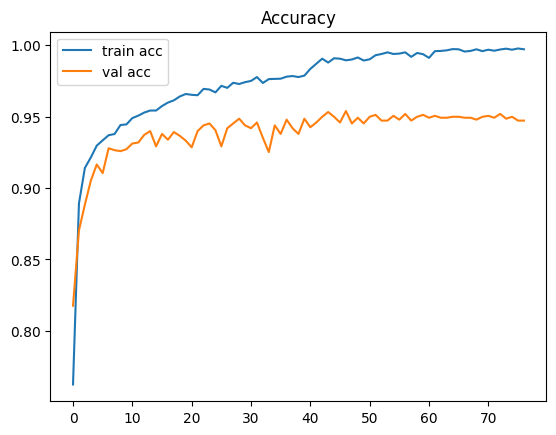

In [36]:
plt.plot(history_c.history["loss"], label="train loss")
plt.plot(history_c.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(history_c.history["accuracy"], label="train acc")
plt.plot(history_c.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy")
plt.show()

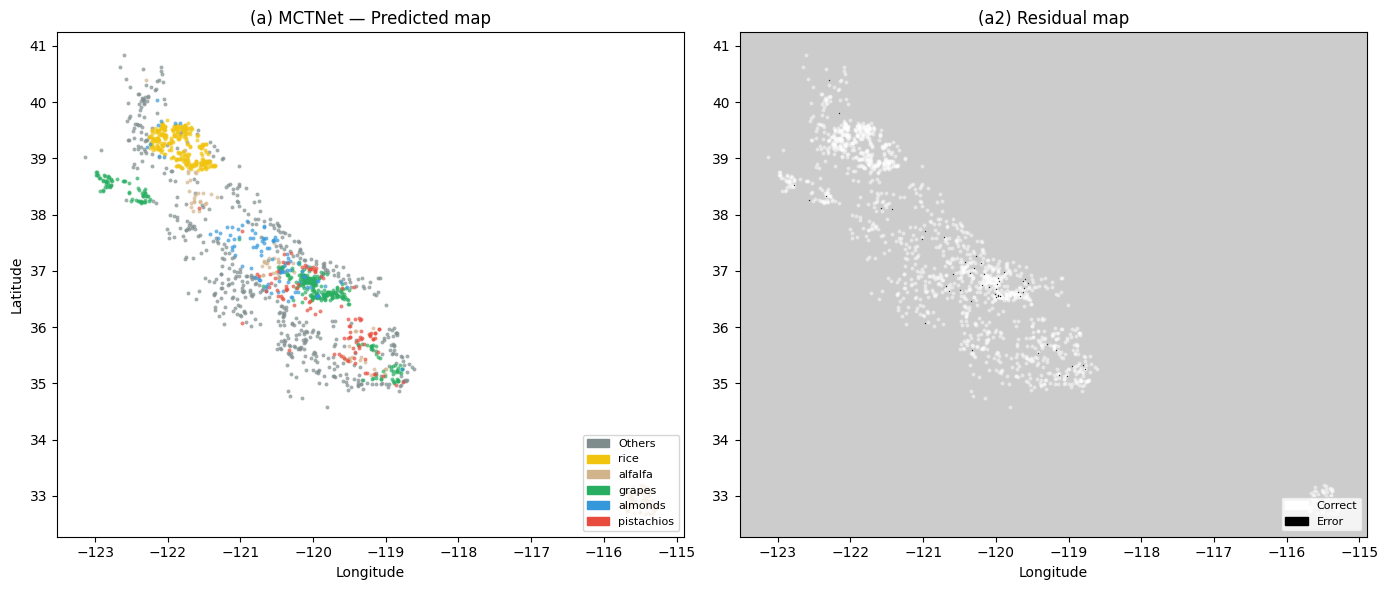

Mapping accuracy : 0.965


In [37]:
LABEL_MAP = {
    0: 'Others',
    1: 'rice',
    2: 'alfalfa',
    3: 'grapes',
    4: 'almonds',
    5: 'pistachios'
}

COLOR_MAP = {
    0: '#7f8c8d',  
    1: '#f1c40f',  
    2: '#d2b48c',  
    3: '#27ae60',  
    4: '#3498db',  
    5: '#e74c3c',  
}


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

lats = coords_test_c[:, 0]
lons = coords_test_c[:, 1]


ax = axes[0]
for classe, color in COLOR_MAP.items():
    mask_classe = y_c_pred == classe
    if mask_classe.sum() > 0:
        ax.scatter(
            lons[mask_classe], lats[mask_classe],
            c=color, s=8, label=LABEL_MAP[classe],
            alpha=0.7, linewidths=0
        )

ax.set_title('(a) MCTNet — Predicted map', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')


patches = [mpatches.Patch(color=COLOR_MAP[c], label=LABEL_MAP[c])
           for c in COLOR_MAP]
ax.legend(handles=patches, loc='lower right', fontsize=8, markerscale=3)


ax = axes[1]
correct = y_c_pred == y_c_test

ax.scatter(
    lons[correct], lats[correct],
    c='white', s=8, alpha=0.5, linewidths=0,
    label='Correct'
)
ax.scatter(
    lons[~correct], lats[~correct],
    c='black', s=1, alpha=0.8, linewidths=0,
    label='Error'
)

ax.set_facecolor('#cccccc')  # fond gris comme le paper
ax.set_title('(a2) Residual map', fontsize=12)
ax.set_xlabel('Longitude')

patches_res = [
    mpatches.Patch(color='white', label='Correct'),
    mpatches.Patch(color='black', label='Error')
]
ax.legend(handles=patches_res, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('crop_map_arkansas.png', dpi=300, bbox_inches='tight')
plt.show()


mapping_accuracy = correct.sum() / len(correct)
print(f"Mapping accuracy : {mapping_accuracy:.3f}")